In [ ]:
import muspan as ms
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import cv2

from persim import plot_diagrams

print("Packages loaded successfully!")


from filters import cycle_intensity, edge_strength, component_intensity, hole_strength, basic_filtering

Packages loaded successfully!


Stage HH3, n=1, image is 702 wide and 584 tall
Number of components before: 1171
Number of components after filtering: 295
Number of cycles before: 487
Number of cycles after filtering: 92
Stage HH3, n=2, image is 702 wide and 608 tall
Number of components before: 10
Number of components after filtering: 4
Number of cycles before: 0
Number of cycles after filtering: 0
Stage HH4, n=1, image is 645 wide and 800 tall
Number of components before: 1881
Number of components after filtering: 595
Number of cycles before: 912
Number of cycles after filtering: 195
Stage HH4, n=2, image is 702 wide and 565 tall
Number of components before: 1789
Number of components after filtering: 436
Number of cycles before: 513
Number of cycles after filtering: 60
Stage HH4, n=3, image is 544 wide and 800 tall
Number of components before: 1850
Number of components after filtering: 423
Number of cycles before: 679
Number of cycles after filtering: 94
Stage HH4, n=4, image is 515 wide and 800 tall
Number of comp

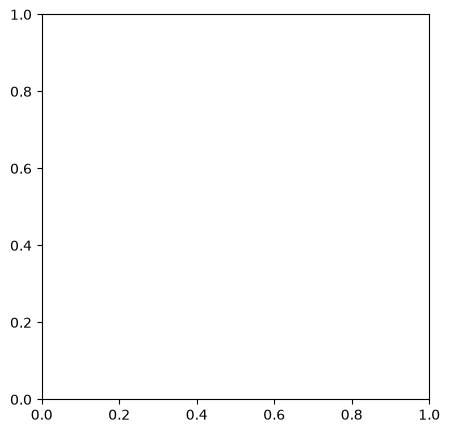

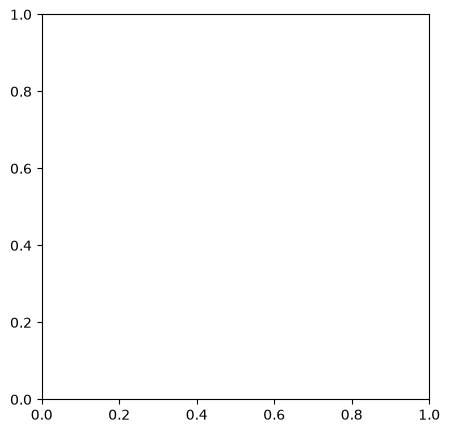

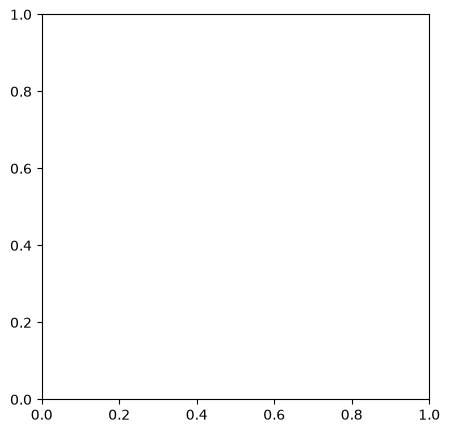

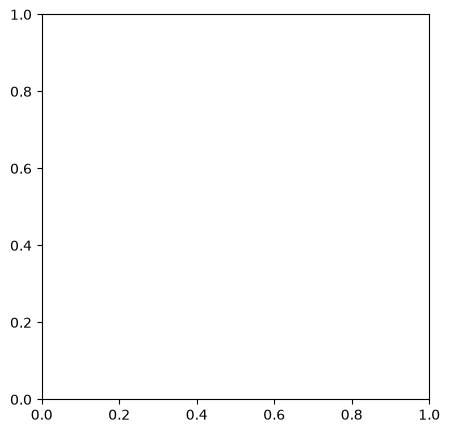

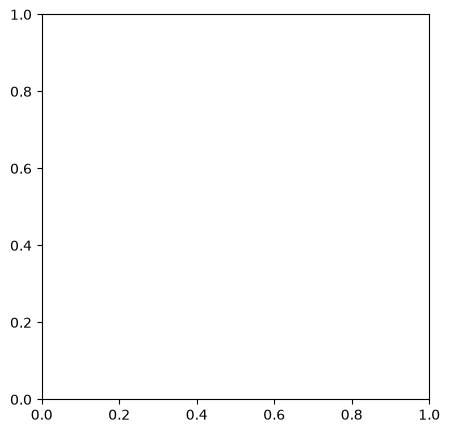

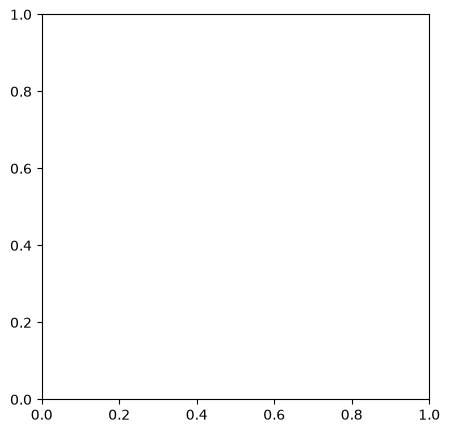

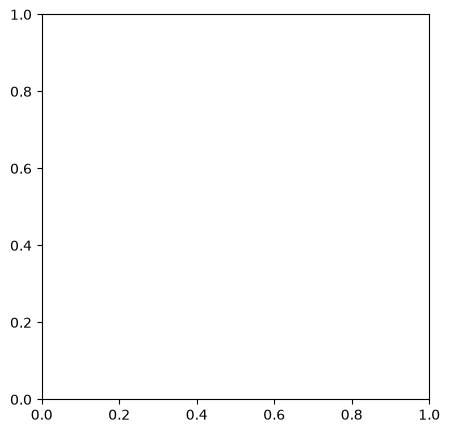

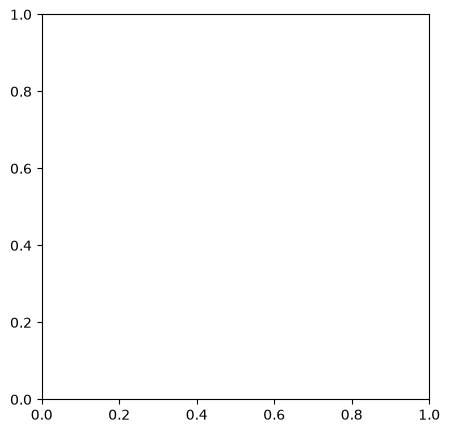

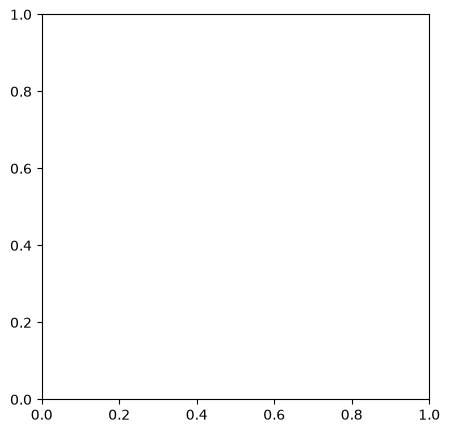

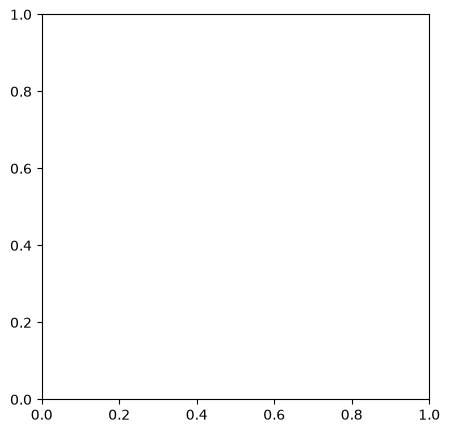

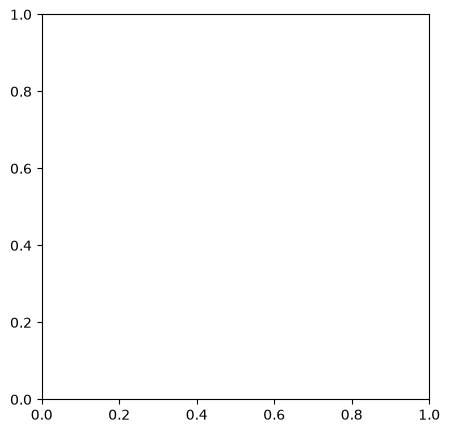

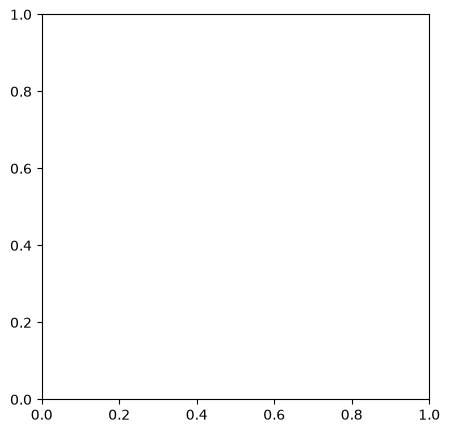

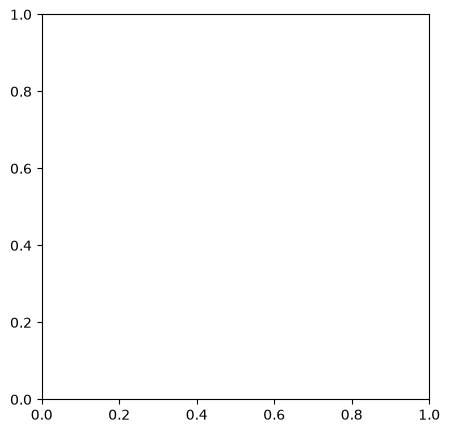

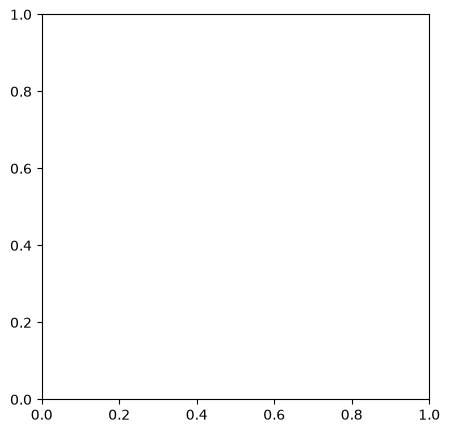

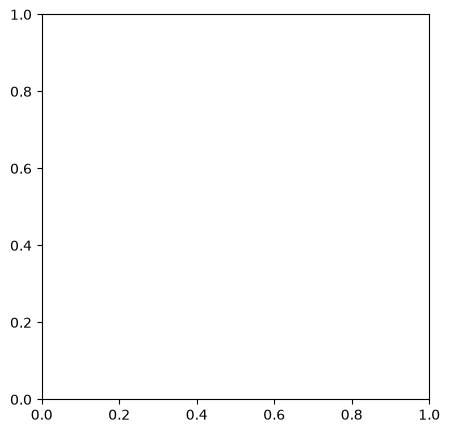

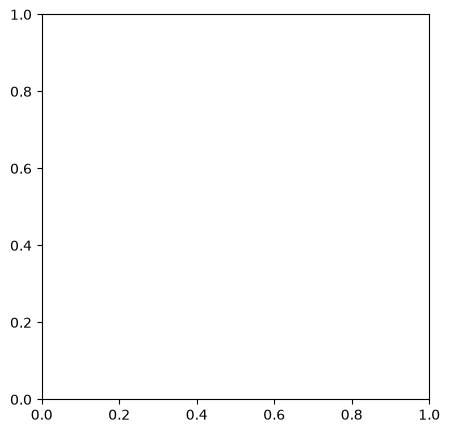

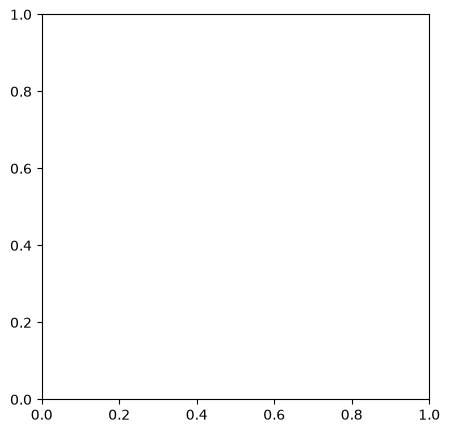

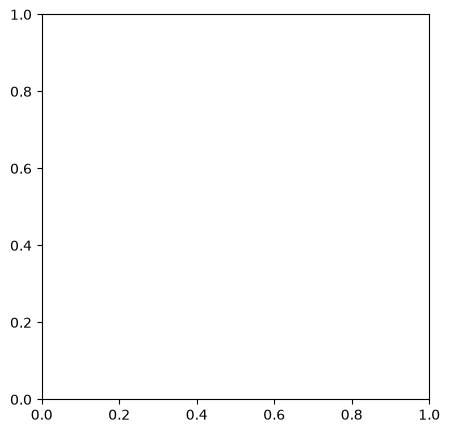

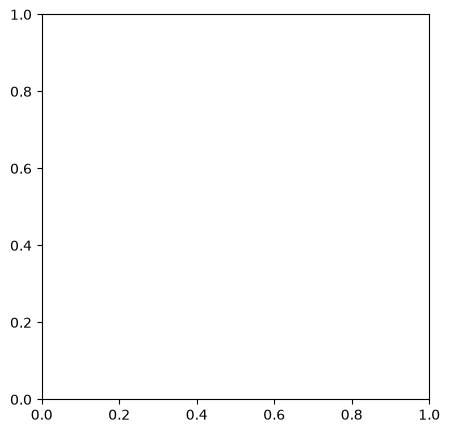

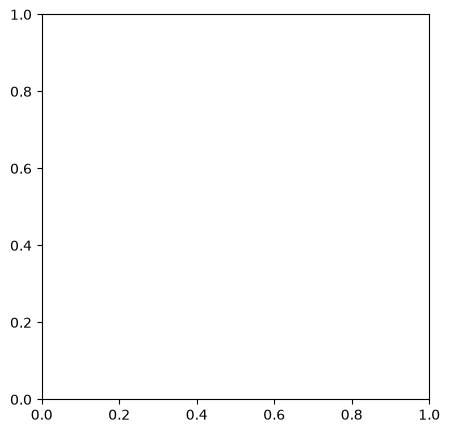

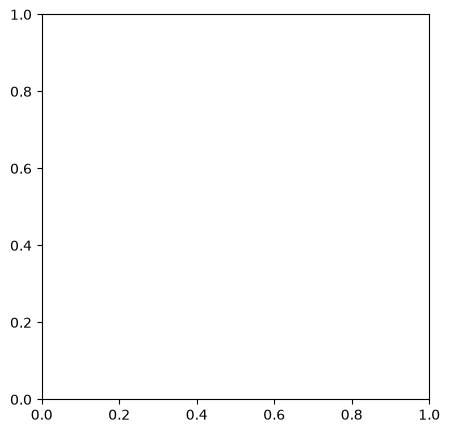

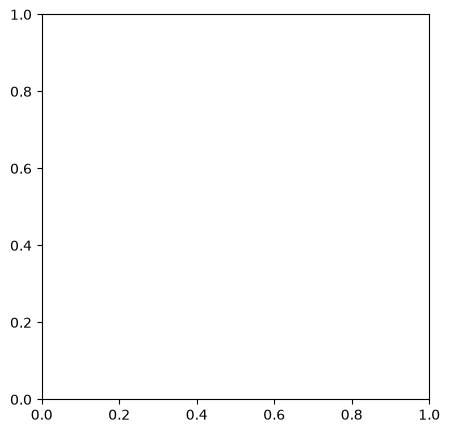

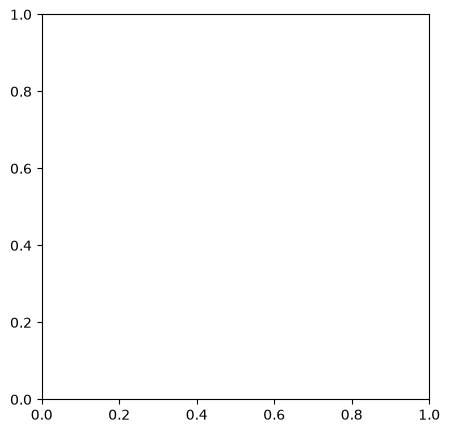

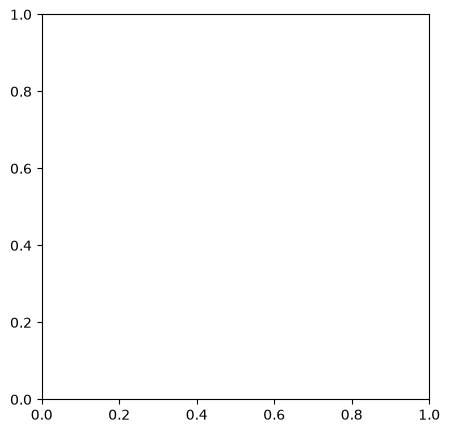

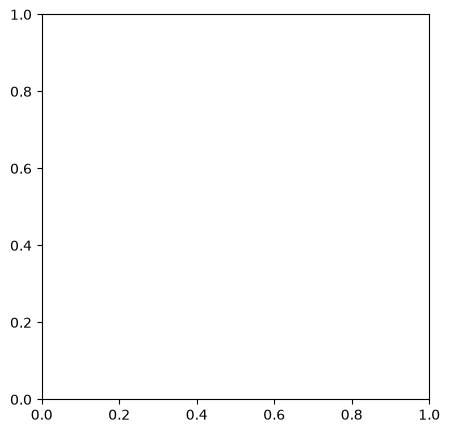

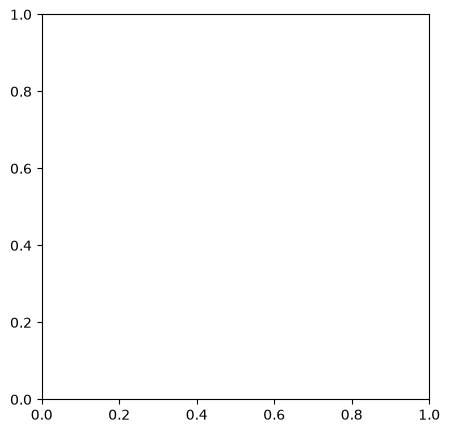

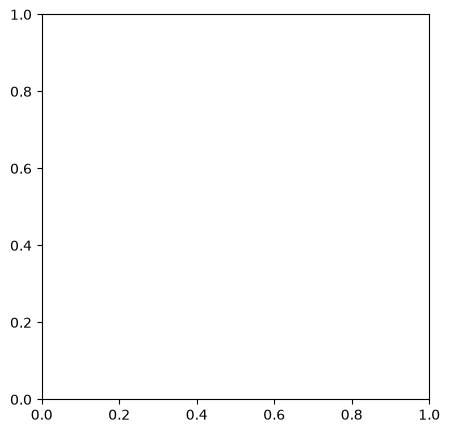

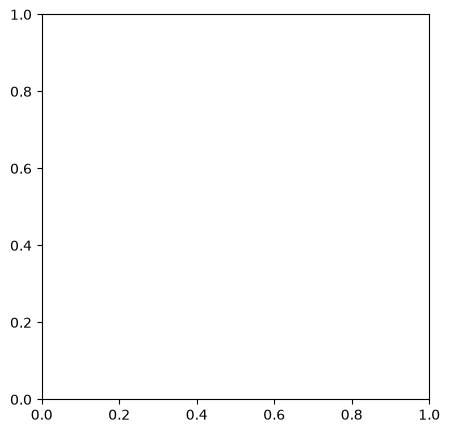

In [5]:
stages = [3,4,5,6,7,8,9,10,11,12,13]

max_n=5
background_colour = "black"

num_components = pd.DataFrame(index=stages,columns=[1,2,3,4,5])
num_cycles = pd.DataFrame(index=stages,columns=[1,2,3,4,5])

components_intensities = []
cycles_intensities = []

edges_strengths = []
holes_strengths = []

vectors = []

particle_size=10



for i in range(len(stages)):
    stage = stages[i]
    n=1
    n_maxxed = False #repeat until files cannot be found
    while not n_maxxed:
        #image = cv2.imread(f'data/ph_test_cycles.png') #test image
        image = cv2.imread(f'data/PH_histograms/{particle_size}um/hh{stage}_n{n}_Cleaned_{particle_size}um.png')
        
        if image is None: #file not found
            n_maxxed=True
        else:

            height = len(image)
            width = len(image[0])

            if height > 800:
                new_height = 800
                new_width = int(800/height * width)
                image = cv2.resize(image, (new_width,new_height)) #downscale to not crash python
                
            #plt.imshow(image)
            
            
            if background_colour == "white": #invert image so we can filter in right direction (PH filters from black to white)
                image = 255-image

            grey_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
            print(f"Stage HH{stage}, n={n}, image is {len(image[0])} wide and {len(image)} tall")




            #run PH
            result = ms.topology.level_set_filtration(grey_image) 
            
            fig,ax=plt.subplots(figsize=(5,5))

            cycles = result["dgms"][0] #reverse the cycle and components (because we filtered black to white instead of white to black: hacky workaround)
            components = result["dgms"][1]

            cycles = cycles[[ r[1]<999 for r in cycles]] #remove the infinite cycle generated
            #print(components)
            #print("\n")
            #print(cycles)



            #appending data structures
            [components,cycles] = basic_filtering(components,cycles,plot=False,min_lifespan=5)
            #filtered_persistence = {"dgms":[components,cycles]}
            #ms.visualise.barcode(filtered_persistence)

            num_components.loc[stage,n] = len(components)
            num_cycles.loc[stage,n] = len(cycles)

            components_intensities.append({"Stage": stage, "n": n, "components intensities": component_intensity(components)})
            cycles_intensities.append({"Stage": stage, "n": n, "cycles intensities": cycle_intensity(cycles)})

            edges_strengths.append({"Stage": stage, "n": n, "edges strengths": edge_strength(components)})
            holes_strengths.append({"Stage": stage, "n": n, "holes strengths": hole_strength(cycles)})

            #if len(components)>0:
            vectorised_ph,_ = ms.topology.vectorise_persistence(result, method='statistics')
            vectors.append({"Stage": stage, "n": n, "drug":"none","vectors": vectorised_ph})
            
            n=n+1


Stage HHcontrol, image is 657 wide and 800 tall
Number of components before: 7055
Number of components after filtering: 1138
Number of cycles before: 2988
Number of cycles after filtering: 934


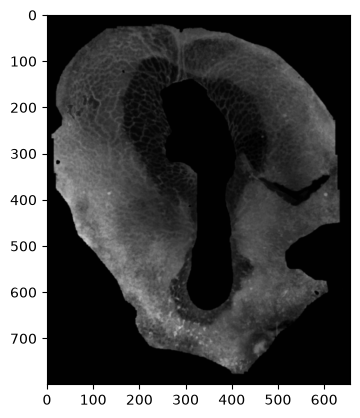

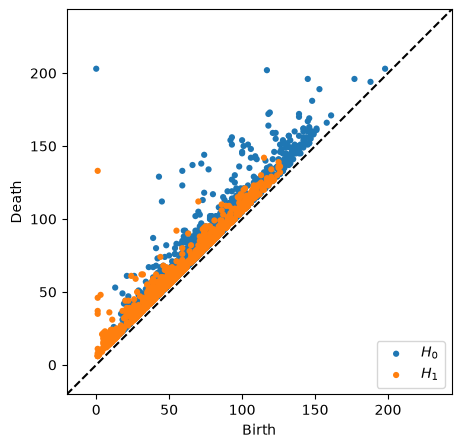

Stage HH10um, image is 702 wide and 702 tall
Number of components before: 4776
Number of components after filtering: 963
Number of cycles before: 1699
Number of cycles after filtering: 726


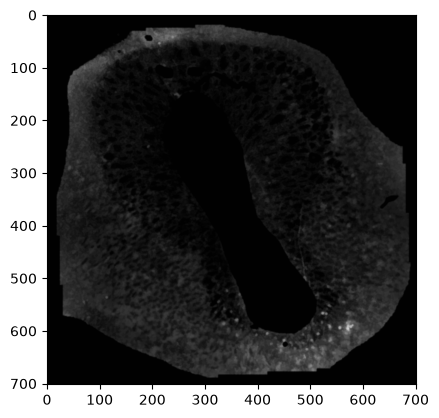

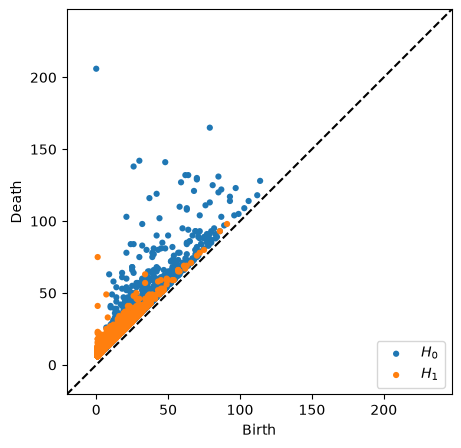

Stage HH20um, image is 620 wide and 800 tall
Number of components before: 5313
Number of components after filtering: 1063
Number of cycles before: 2327
Number of cycles after filtering: 671


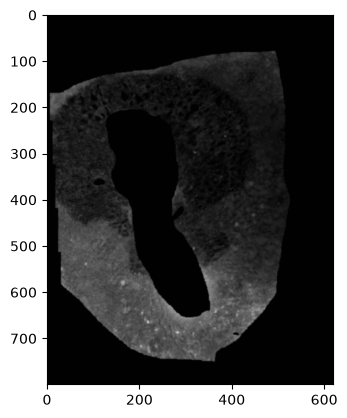

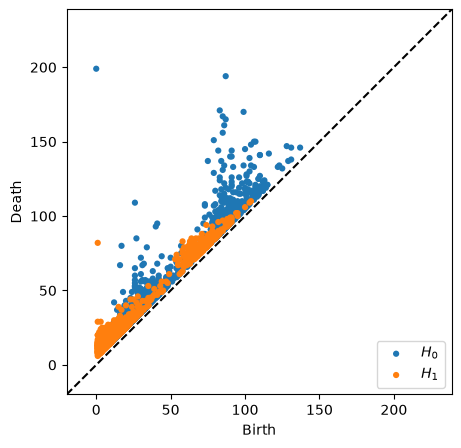

In [6]:

max_n=5
background_colour = "black"


#conditions = ["Control","10um","20um","30um"]
#drug_name = "mmp brendan2"
#drug_stage=9


#conditions = ["10um","30um","50um"]
#drug_name = "mmp brendan"
#drug_stage=11

conditions = ["control","10um","20um"]
drug_name = "mmp hh8+24hr"
drug_stage=13



num_components = pd.DataFrame(index=conditions)
num_cycles = pd.DataFrame(index=conditions)


for i in range(len(conditions)):
    stage = conditions[i]
    n=1

    #image = cv2.imread(f'data/ph_test_cycles.png') #test image
    image = cv2.imread(f'data/PH_drugs/{drug_name}/{particle_size}um/{stage}_Cleaned_{particle_size}um.png')
    

    height = len(image)
    width = len(image[0])

    if height > 800:
        new_height = 800
        new_width = int(800/height * width)
        image = cv2.resize(image, (new_width,new_height)) #downscale to not crash python
        
    plt.imshow(image)
    
    
    if background_colour == "white": #invert image so we can filter in right direction (PH filters from black to white)
        image = 255-image

    grey_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    print(f"Stage HH{stage}, image is {len(image[0])} wide and {len(image)} tall")




    #run PH
    result = ms.topology.level_set_filtration(grey_image) 
    
    fig,ax=plt.subplots(figsize=(5,5))

    cycles = result["dgms"][0] #reverse the cycle and components (because we filtered black to white instead of white to black: hacky workaround)
    components = result["dgms"][1]

    cycles = cycles[[ r[1]<999 for r in cycles]] #remove the infinite cycle generated
    #print(components)
    #print("\n")
    #print(cycles)



    #appending data structures
    [components,cycles] = basic_filtering(components,cycles,plot=True,min_lifespan=5)
    #filtered_persistence = {"dgms":[components,cycles]}
    #ms.visualise.barcode(filtered_persistence)

    num_components.loc[stage,n] = len(components)
    num_cycles.loc[stage,n] = len(cycles)

    components_intensities.append({"Stage": stage, "n": n, "components intensities": component_intensity(components)})
    cycles_intensities.append({"Stage": stage, "n": n, "cycles intensities": cycle_intensity(cycles)})

    edges_strengths.append({"Stage": stage, "n": n, "edges strengths": edge_strength(components)})
    holes_strengths.append({"Stage": stage, "n": n, "holes strengths": hole_strength(cycles)})

    #if len(components)>0:
    vectorised_ph,feature_names = ms.topology.vectorise_persistence(result, method='statistics')
    vectors.append({"Stage": drug_stage, "n": n, "drug":conditions[i], "vectors": vectorised_ph})
    
    n=n+1


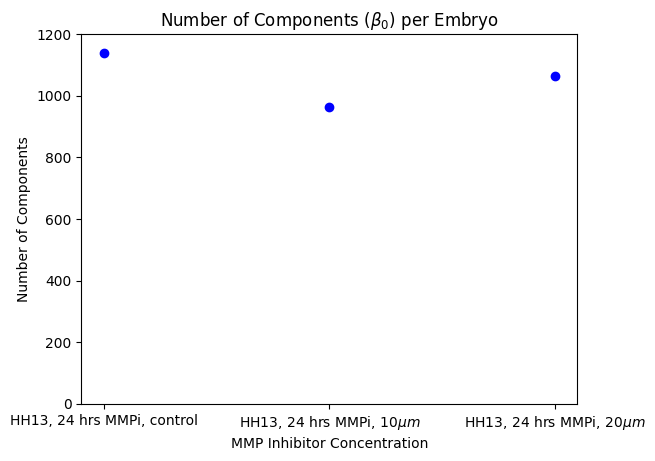

In [20]:
labels = "HH13, 24 hrs MMPi, " + np.array(["control", "$10 \\mu m$","$20 \\mu m$"])
#labels = "HH11, 14 hrs MMPi, " + num_components.index
#labels = "HH9, " + num_components.index
plt.plot(labels,num_components,'o',color="blue")
plt.xlabel("MMP Inhibitor Concentration")
plt.ylabel("Number of Components")
plt.ylim(bottom=0,top=1200)
plt.title(f"Number of Components ($\\beta_0$) per Embryo")
# Ensures your X-axis only shows the actual stage numbers
plt.show()

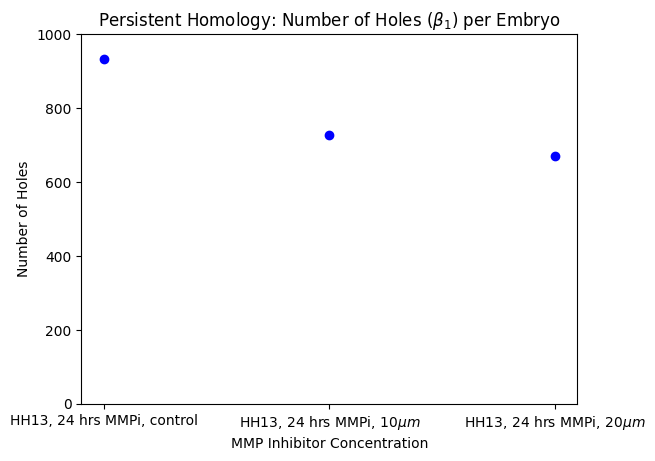

In [21]:
labels = "HH13, 24 hrs MMPi, " + np.array(["control", "$10 \\mu m$","$20 \\mu m$"])
#labels = "HH11, 14 hrs MMPi, " + num_components.index
#labels = "HH9, " + num_components.index
plt.plot(labels,num_cycles,'o',color="blue")
plt.xlabel("MMP Inhibitor Concentration")
plt.ylabel("Number of Holes")
plt.ylim(bottom=0,top=1000)
plt.title(f"Persistent Homology: Number of Holes ($\\beta_1$) per Embryo")
 # Ensures your X-axis only shows the actual stage numbers
plt.show()

In [8]:
def plot_iqr(feature_list,stages,label,title):
    medians = []
    lower_errors = []
    upper_errors = []
    
    df=pd.DataFrame(feature_list)
    df_exploded = df.explode(label).dropna(subset=[label])

    for stage in stages:
        stage_data = df_exploded[df_exploded["Stage"]==stage][label]
        if len(stage_data)>0:

            med = np.median(stage_data)
            medians.append(med)

            lower_errors.append(med-np.percentile(stage_data,25))
            upper_errors.append(np.percentile(stage_data,75)-med)
        else:
            medians.append(0)
            lower_errors.append(0)
            upper_errors.append(0)

    plt.errorbar(stages,medians,yerr=[lower_errors,upper_errors],linewidth=2.5,capsize=4,capthick=2.5)
    plt.xlabel("HH Stage")
    plt.xticks(stages)
    plt.ylabel(title)
    plt.title(f"{title} Per Embryo")
        




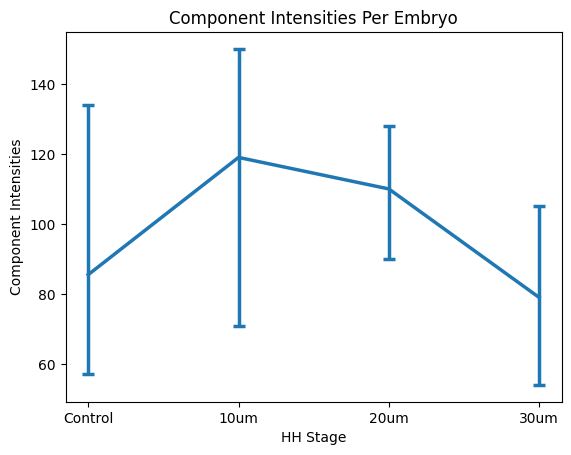

In [9]:
plot_iqr(components_intensities,conditions,"components intensities","Component Intensities")

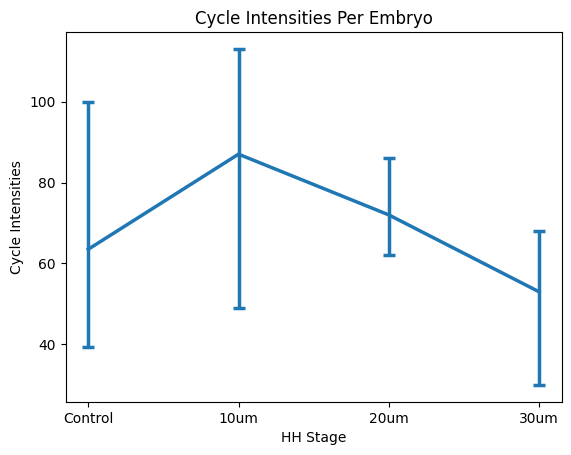

In [10]:
plot_iqr(cycles_intensities,conditions,"cycles intensities","Cycle Intensities")

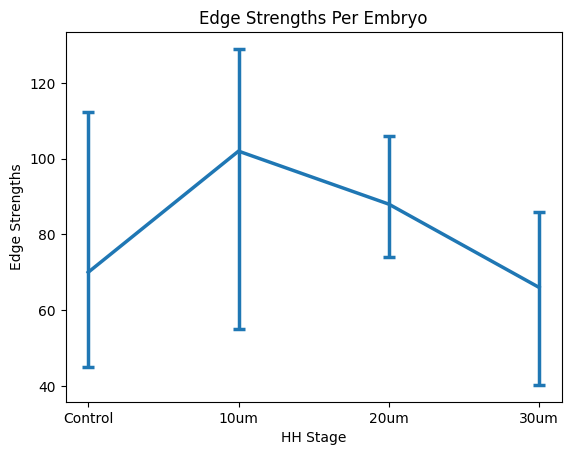

In [11]:
plot_iqr(edges_strengths,conditions,"edges strengths","Edge Strengths")

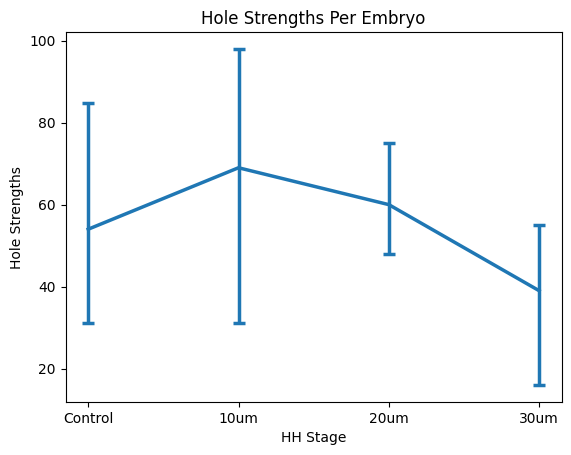

In [12]:
plot_iqr(holes_strengths,conditions,"holes strengths","Hole Strengths")

    Stage  n     drug                                            vectors
0       3  1     none  [9.256147540983607, 8.041259071416707, 2.0, 3....
2       4  1     none  [9.477546549835706, 7.936342412715304, 1.0, 3....
3       4  2     none  [5.988326848249027, 5.0802758053996415, 1.0, 2...
4       4  3     none  [9.713235294117647, 8.609936195906323, 1.90000...
5       4  4     none  [15.18978102189781, 15.654239810340195, 2.0, 4...
6       5  1     none  [14.958918918918918, 13.953608035545576, 2.0, ...
7       5  2     none  [24.766519823788546, 19.836515249095054, 2.0, ...
8       6  1     none  [11.220357941834452, 17.18512146805712, 1.0, 2...
9       6  2     none  [25.91977077363897, 20.479618324315346, 2.0, 9...
10      6  3     none  [7.581081081081081, 9.222485384596796, 1.0, 1....
11      7  1     none  [12.850828729281767, 18.99796039876933, 1.0, 2...
12      7  2     none  [20.70108695652174, 16.436233796926263, 1.7000...
13      8  1     none  [18.68974358974359, 35.80601

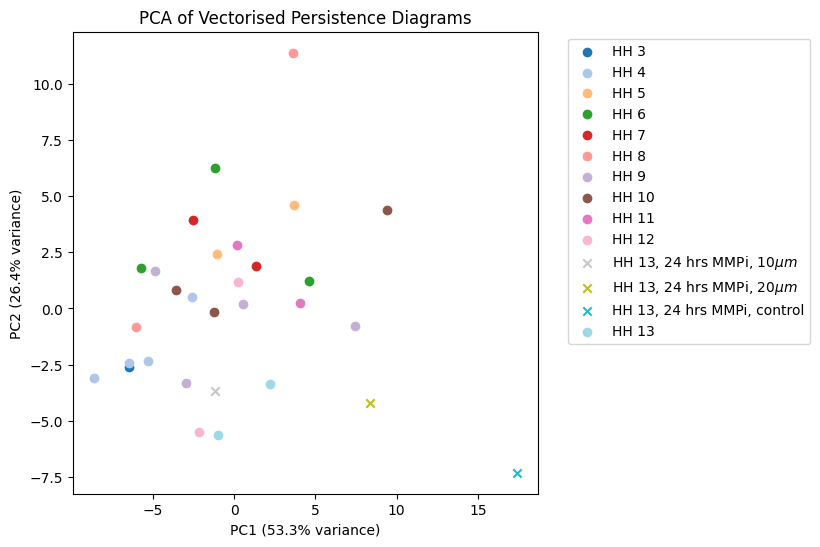

In [29]:
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.cm as cm
from sklearn.preprocessing import StandardScaler

if drug_name == "mmp brendan":
    new_conds = [3,4,5,6,7,8,9,10,11,12,13,"10um","30um","50um"]
    labels = [3,4,5,6,7,8,9,10,11,12,13,"11 14 hrs MMPi 10um","11 14 hrs MMPi 30um","11 14 hrs MMPi 50um"]
    desc = "14 hrs MMPi"
    drug_stage=11
elif drug_name=="mmp hh8+24hr":
    new_conds = [3,4,5,6,7,8,9,10,11,12,13,"control","10um","20um"]
    labels = [3,4,5,6,7,8,9,10,11,12,13,"13 24 hrs MMPi control","13 24 hrs MMPi 10 $\\mu m$","13 24 hrs MMPi 20  $\\mu m"]
    desc = "24 hrs MMPi"
    drug_stage=13
elif drug_name=="mmp brendan2":
    new_conds = [3,4,5,6,7,8,9,10,11,12,13,"control","10um","20um","30um"]
    labels = [3,4,5,6,7,8,9,10,11,12,13,"9 14 hrs MMPi Control","9 14 hrs MMPi 10um","9 14 hrs MMPi 20um","9 14 hrs MMPi 30um"]
    desc = "24 hrs MMPi"
    drug_stage=9

vec=pd.DataFrame(vectors).sort_values(["Stage","drug"])

# 1. Create a True/False mask: True if the vector has NO NaNs
# .apply() runs this quick check on every single row in the "vectors" column
valid_mask = vec["vectors"].apply(lambda x: not np.isnan(x).any())

# 2. Overwrite vec to only keep the rows where the mask is True
vec = vec[valid_mask]


#gets the vector data as a list of lists
vecs_only = np.vstack(vec["vectors"]).tolist()

#standardisation
scaler = StandardScaler()
vecs_scaled = scaler.fit_transform(vecs_only)

# Perform PCA to reduce the dimensionality to 2 components
pca = PCA(n_components=2)
pca_result = pca.fit_transform(vecs_scaled)

# Plot the PCA result
fig, ax = plt.subplots(figsize=(6, 6))
n=0
cmap = cm.tab20(np.linspace(0, 1, len(new_conds)))

col_count=0
group_key = vec['Stage'].astype(str) + "_" + vec['drug']
colour_index = pd.factorize(group_key)
print(vec)
legend = []
for i in range(len(vec)):
    info=vec.iloc[i]

    if info.loc["drug"]=="none":
        label = f"HH {info.loc['Stage']}"
        marker="o"
    else:
        drug = info.loc['drug'].replace('um','$\\mu m$')
        label = f"HH {info.loc['Stage']}, {desc}, {drug}"
        marker="x"

    ax.scatter(pca_result[i,0], pca_result[i,1],label=label,color=cmap[colour_index[0][i]],marker=marker) #plot pc1 and pc2

# Add labels and title to the plot
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')

## Remove duplicates
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys(),bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title('PCA of Vectorised Persistence Diagrams')
plt.show()




In [98]:
pc1 = pd.Series(index=feature_names,data=np.round(pca.components_[0],4))
print(f'PC1 represents {pca.explained_variance_ratio_[0]*100:.1f}% of variance')
print(f"Sum:{sum(pc1**2)}")
print(pc1)

pc2 = pd.Series(index=feature_names,data=np.round(pca.components_[1],4))
print(f'PC2 represents {pca.explained_variance_ratio_[1]*100:.1f}% of variance')
print(f"Sum:{sum(pc2**2)}")
print(pc2)

PC1 represents 55.9% of variance
Sum:0.9999200599999997
H0 birth mean                   0.1732
H0 birth sd                     0.1453
H0 birth 10 percentile          0.1460
H0 birth 25 percentile          0.1598
H0 birth 50 percentile          0.1656
H0 birth 75 percentile          0.1658
H0 birth 90 percentile          0.1687
H0 death mean                   0.1744
H0 death sd                     0.1320
H0 death 10 percentile          0.1548
H0 death 25 percentile          0.1641
H0 death 50 percentile          0.1655
H0 death 75 percentile          0.1683
H0 death 90 percentile          0.1632
H0 midpoint mean                0.1743
H0 midpoint sd                  0.1406
H0 midpoint 10 percentile       0.1561
H0 midpoint 25 percentile       0.1638
H0 midpoint 50 percentile       0.1656
H0 midpoint 75 percentile       0.1683
H0 midpoint 90 percentile       0.1673
H0 persistence mean             0.0517
H0 persistence sd               0.0328
H0 persistence 10 percentile   -0.0000
H0 persi